In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda x: f'{x}')

In [2]:
articles = pd.read_csv("articles_hm.csv", encoding="utf-8")
customer = pd.read_csv("customer_hm.csv", encoding="utf-8")
transactions = pd.read_csv("transactions_hm.csv", encoding="utf-8")

In [3]:
# 처리 전 크기
print("customer shape:", customer.shape)
print("articles shape:", articles.shape)
print("transactions shape:", transactions.shape)

customer shape: (1048575, 6)
articles shape: (105542, 25)
transactions shape: (1048575, 5)


In [4]:
#처리 전 데이터 내 컬럼타입
print("customer type:", customer.dtypes)
print("articles type:", articles.dtypes)
print("transactions type:", transactions.dtypes)

customer type: customer_id               object
FN                         int64
Active                     int64
club_member_status        object
fashion_news_frequency    object
age                        int64
dtype: object
articles type: article_id                       int64
product_code                     int64
prod_name                       object
product_type_no                  int64
product_type_name               object
product_group_name              object
graphical_appearance_no          int64
graphical_appearance_name       object
colour_group_code                int64
colour_group_name               object
perceived_colour_value_id        int64
perceived_colour_value_name     object
perceived_colour_master_id       int64
perceived_colour_master_name    object
department_no                    int64
department_name                 object
index_code                      object
index_name                      object
index_group_no                   int64
index_group_name 

In [5]:
#처리 전 데이터 기본 구조
print("customer:", customer.info())
print("articles:", articles.info())
print("transactions:", transactions.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   customer_id             1048575 non-null  object
 1   FN                      1048575 non-null  int64 
 2   Active                  1048575 non-null  int64 
 3   club_member_status      1048575 non-null  object
 4   fashion_news_frequency  1048574 non-null  object
 5   age                     1048575 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 48.0+ MB
customer: None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 n

In [6]:
#Null 값 확인
transactions.isnull().sum()
articles.isnull().sum()
customer.isnull().sum()

customer_id               0
FN                        0
Active                    0
club_member_status        0
fashion_news_frequency    1
age                       0
dtype: int64

In [7]:
#customer에서 어떤 행이 null 값을 가지는지 확인
customer[customer.isnull().any(axis=1)]

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age
876108,a79d9cbfaceb0d25a91caccfad167d4d6391fd5bb4292b...,1,0,ACTIVE,NaN,38


In [8]:
#결측치 대체 위해 빈도 구하기
customer.groupby('fashion_news_frequency')['customer_id'].count()

fashion_news_frequency
Monthly         658
NONE         674698
Regularly    373218
Name: customer_id, dtype: int64

In [9]:
#뉴스 구독빈도 결측치 채우는 함수 지정
#FN=0이면 0의 결과값인 NONE 반환
#FN=1이면 1의 결과값 중 최빈값인 Regularly 반환
def fnn(row):
    if pd.isna(row['fashion_news_frequency']):   # 결측치라면
        if row['FN'] == 0:
            return 'NONE'
        elif row['FN'] == 1:
            return 'Regularly'
    return row['fashion_news_frequency'] 

In [10]:
#customers null값 사라졌는지 확인 
customer['fashion_news_frequency'] = customer.apply(fnn, axis=1)
#다시 결측치 여부 확인
print(customer.isnull().sum()) 

customer_id               0
FN                        0
Active                    0
club_member_status        0
fashion_news_frequency    0
age                       0
dtype: int64


In [11]:
#중복행 확인 및 제거 
customer = customer.drop_duplicates()
transactions = transactions.drop_duplicates()
articles = articles.drop_duplicates()

In [12]:
#중복행 제거 후 크기 확인 
print("customer shape:", customer.shape)
print("articles shape:", articles.shape)
# transactions : 1048575=>1040101
print("transactions shape:", transactions.shape)

customer shape: (1048575, 6)
articles shape: (105542, 25)
transactions shape: (1040101, 5)


In [13]:
#연령 이상치 제거
customer = customer[(customer["age"] >= 14) & (customer["age"] <= 90)]

In [14]:
#판매 채널값들 확인(1,2 아닌 결측치 or 이상치 확인)
transactions.groupby('sales_channel_id')['customer_id'].count()

sales_channel_id
1    318613
2    721488
Name: customer_id, dtype: int64

In [15]:
#구매일 날짜 타입으로 변환
transactions["t_dat"] = pd.to_datetime(transactions["t_dat"])

In [16]:
#IQR로 이상치 탐지
#가격 이상치 제거 (범위에서 벗어난 가격 제거)
#가격 이상치 여부 - IQR  
q3 = transactions['price'].quantile(0.75) 
q1 = transactions['price'].quantile(0.25)

iqr = q3 - q1
q3, q1, iqr
def is_outlier(transactions):
    price = transactions['price']
    if price > q3 + (1.5 * iqr) or price < q1 - (1.5 * iqr):
        return '이상치'
    else:
        return '이상치아님'
    
#이상치 여부 함수를 통해 나타냄
transactions['이상치여부'] = transactions.apply(is_outlier, axis = 1)

In [17]:
#이상치 : 49452개
transactions.groupby('이상치여부')['customer_id'].count()

이상치여부
이상치       49452
이상치아님    990649
Name: customer_id, dtype: int64

In [18]:
# 로그 변환 + zscore 정규화
transactions['price_log'] = np.log(transactions['price'])

df1 = transactions[['price_log']]
df2= transactions[['price']]
scaler = StandardScaler()
zscore_values = scaler.fit_transform(df1)
just_values = scaler.fit_transform(df2)
transactions['just2']=just_values
transactions['zscore'] = zscore_values
transactions
#이상치 : 6583개
transactions['is_outlier'] = (transactions['zscore'] > 3) | (transactions['zscore'] < -3)
transactions['is_outlier'].sum()

np.int64(6583)

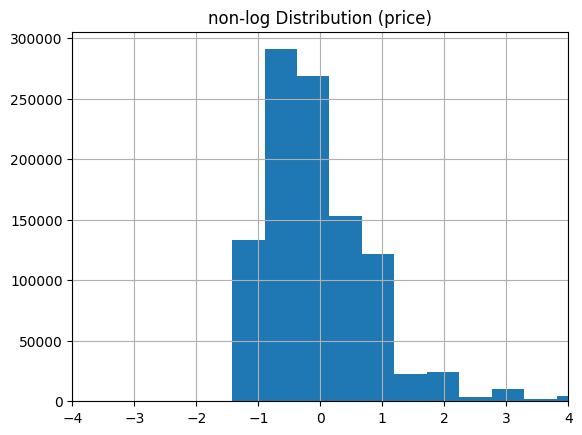

In [19]:
#price를 그대로 plot
plt.figure()
transactions['just2'].hist(bins=50)
plt.title('non-log Distribution (price)')
plt.xlim(-4,4)
plt.show()

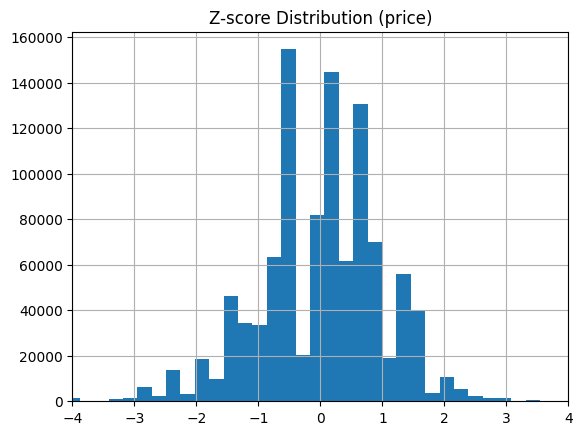

In [20]:
#Z-score 및 log_scale 이용 plot
plt.figure()
transactions['zscore'].hist(bins=50)
plt.title('Z-score Distribution (price)')
plt.xlim(-4,4)
plt.show()

In [21]:
# IQR 49452개 & Z_score 6583개 동시에 만족
# 이상치 1698개 탐지 
transactions[((transactions['zscore'] < -3) | (transactions['zscore'] > 3)) & (transactions['이상치여부'] == '이상치')
].count()

t_dat               1698
customer_id         1698
article_id          1698
price               1698
sales_channel_id    1698
이상치여부               1698
price_log           1698
just2               1698
zscore              1698
is_outlier          1698
dtype: int64

In [22]:
# IQR, Z_score 모두 이상치인 값들 제거
outlier_con = ((transactions['zscore'] < -3) | (transactions['zscore'] > 3)) & (transactions['이상치여부'] == '이상치')

outlier_index = transactions[outlier_con].index
transactions = transactions.drop(outlier_index)
print(transactions)
transactions.to_csv('transactions.csv', index=False)

             t_dat                                        customer_id  \
0       2019-11-05  3e2b60b679e62fb49516105b975560082922011dd752ec...   
1       2019-05-22  89647ac2274f54c770aaa4b326e0eea09610c252381f37...   
2       2019-05-10  2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...   
3       2019-08-26  7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...   
4       2019-08-10  3b77905de8b32045f08cedb79200cdfa477e9562429a39...   
...            ...                                                ...   
1048569 2019-01-23  9a34b77f0d5f7aa03ff810e47fdf64be1557cf9fb0fe87...   
1048570 2019-03-25  8e900818a1da0e73300a012794615993fbefb43f851430...   
1048571 2019-10-18  13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...   
1048572 2019-04-06  5f51e21397c1248aafdf9712435bd4be063eb093f56229...   
1048574 2019-01-13  5813663221b265eba9e4604e482be951d9a97ae022a88a...   

         article_id       price  sales_channel_id  이상치여부           price_log  \
0         698328010 0.016932203            

In [23]:
# 처리 후 크기
print("customer shape:", customer.shape)
print("articles shape:", articles.shape)
# 1040101 => 1038403
print("transactions shape:", transactions.shape)

customer shape: (1048523, 6)
articles shape: (105542, 25)
transactions shape: (1038403, 10)


In [24]:
# IQR=이상치, Z_score=이상치아님 값들 대체
transactions.groupby('이상치여부')['customer_id'].count()

이상치여부
이상치       47754
이상치아님    990649
Name: customer_id, dtype: int64

In [25]:
# IQR이 임계값을 넘긴 것들은 q3+1.5iqr, q1-1.5iqr로 바꿔준다!

# IQR 계산
re_q3 = transactions['price'].quantile(0.75)
re_q1 = transactions['price'].quantile(0.25)
re_iqr = re_q3 - re_q1
lower = re_q1 - 1.5 * re_iqr
upper = re_q3 + 1.5 * re_iqr

# 행별 처리 : 조건에 맞춰 이상치 대체
for idx, row in transactions.iterrows():
    if row['이상치여부'] == '이상치':
        if row['price'] > upper:
            transactions.at[idx, 'price'] = upper
        elif row['price'] < lower:
            transactions.at[idx, 'price'] = lower
            
transactions['이상치여부2'] = transactions.apply(is_outlier, axis = 1)
transactions.groupby('이상치여부2')['customer_id'].count()

이상치여부2
이상치아님    1038403
Name: customer_id, dtype: int64

In [26]:
#Z-score만 이상치인 것들 대체
transactions['zscore_outlier'] = transactions['zscore'].apply(lambda x: '이상치' if (x > 3) or (x < -3) else 'normal')
transactions.groupby('zscore_outlier')['customer_id'].count()

zscore_outlier
normal    1033518
이상치          4885
Name: customer_id, dtype: int64

In [27]:
# 임계값 설정 : 상한, 하한
z_upper = transactions[transactions['zscore'] <= 3]['price'].max()
z_lower = transactions[transactions['zscore'] >= -3]['price'].min()

z_upper, z_lower

(np.float64(0.061847458), np.float64(0.003135593))

In [28]:
# 이상치에 따라 가격 매핑
transactions['price_zc'] = transactions['price']

transactions.loc[transactions['zscore_outlier'] == '이상치', 'price_zc']=transactions.loc[transactions['zscore_outlier'] =='이상치', 'price_zc'].clip(z_lower, z_upper)

In [29]:
transactions.groupby('price_zc')['customer_id'].count()

price_zc
0.003135593     4915
0.003152542       24
0.003169492       34
0.003186441       40
0.00320339        64
               ...  
0.061762712       19
0.061779661        2
0.061813559        1
0.061830508        1
0.061847458    47755
Name: customer_id, Length: 3329, dtype: int64

In [30]:
# 쓸모없는 컬럼 다 제거
transactions = transactions.drop(columns=['price','이상치여부','price_log','just2','zscore','is_outlier','이상치여부2','zscore_outlier'])

In [31]:
transactions = transactions.rename(columns={'price_zc': 'price'})
transactions

,t_dat,customer_id,article_id,sales_channel_id,price
0,2019-11-05,3e2b60b679e62fb49516105b975560082922011dd752ec...,698328010,2,0.016932203
1,2019-05-22,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,760597002,2,0.033881356
2,2019-05-10,2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...,488561032,2,0.016932203
3,2019-08-26,7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...,682771001,2,0.033881356
4,2019-08-10,3b77905de8b32045f08cedb79200cdfa477e9562429a39...,742400033,1,0.003220339
...,...,...,...,...,...
1048569,2019-01-23,9a34b77f0d5f7aa03ff810e47fdf64be1557cf9fb0fe87...,577675001,2,0.023711864
1048570,2019-03-25,8e900818a1da0e73300a012794615993fbefb43f851430...,766346001,2,0.02540678
1048571,2019-10-18,13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...,811905001,2,0.016932203
1048572,2019-04-06,5f51e21397c1248aafdf9712435bd4be063eb093f56229...,690108001,2,0.021728814


In [32]:
transactions.to_csv('transactions.csv', index=False)

In [33]:
#customer와 transactions join: 고객 세그먼트별 매출액 알아보기
#1038403=> 805043  약 20% 고객이 1년간 결제하지 않음.
merge_t_c = pd.merge(transactions,customer, how='inner', on='customer_id')
merge_t_c

,t_dat,customer_id,article_id,sales_channel_id,price,FN,Active,club_member_status,fashion_news_frequency,age
0,2019-11-05,3e2b60b679e62fb49516105b975560082922011dd752ec...,698328010,2,0.016932203,1,1,ACTIVE,Regularly,51
1,2019-05-22,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,760597002,2,0.033881356,0,0,ACTIVE,NONE,28
2,2019-05-10,2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...,488561032,2,0.016932203,1,1,ACTIVE,Regularly,37
3,2019-08-26,7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...,682771001,2,0.033881356,0,0,ACTIVE,NONE,19
4,2019-08-10,3b77905de8b32045f08cedb79200cdfa477e9562429a39...,742400033,1,0.003220339,0,0,ACTIVE,NONE,35
...,...,...,...,...,...,...,...,...,...,...
805038,2019-01-23,9a34b77f0d5f7aa03ff810e47fdf64be1557cf9fb0fe87...,577675001,2,0.023711864,1,1,ACTIVE,Regularly,46
805039,2019-03-25,8e900818a1da0e73300a012794615993fbefb43f851430...,766346001,2,0.02540678,0,0,ACTIVE,NONE,21
805040,2019-10-18,13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...,811905001,2,0.016932203,1,1,ACTIVE,Regularly,39
805041,2019-04-06,5f51e21397c1248aafdf9712435bd4be063eb093f56229...,690108001,2,0.021728814,1,1,ACTIVE,Regularly,44


In [34]:
merge_t_c_a = pd.merge(merge_t_c, articles, how = 'inner', on='article_id')

In [35]:
#product_group_name의 Unknown 값들을 detail_desc 참조하여 대체

unknown_df = merge_t_c_a[merge_t_c_a['product_group_name'] == 'Unknown']
print(unknown_df)
unknown_df.to_csv('unknown_df.csv',index=False, encoding='utf-8')

            t_dat                                        customer_id  \
40     2019-05-01  8fd4362fa0143a6fb4ca702371a0907eb27ae47e8d5b1b...   
494    2019-12-23  10f78ed9f13af59e27b9e8dd20870ab12232e69bf44522...   
1195   2019-09-13  24a37818e25036257faf1164ab360901e4fa751a532f0a...   
1578   2019-08-20  754fcd0098260f58cac436b8d6d1c89189c57084827574...   
1702   2019-01-21  0efd5b2076ff41f7e741a796be3416418ec2ea942cb59a...   
...           ...                                                ...   
800337 2019-09-08  9a07ee1f7a908beb09532581b0c5fc782ebb436b83ecc8...   
800436 2019-07-28  2ea8ac56ddf73532ba6677408959003e9839836c9b3fe4...   
800533 2019-11-03  474375c76329865df93506bc228f96bd19fd74257d5197...   
801688 2019-11-18  a99c003460c5a2cf90e0240f28033c61f2b065ba24f7da...   
802690 2019-06-04  7fb2922b56c1555db904ae746f6277cfb1b0a87f232a4a...   

        article_id  sales_channel_id       price  FN  Active  \
40       707269001                 2 0.033881356   0       0   
494    

In [36]:
unknown_df2 = merge_t_c_a[merge_t_c_a['product_type_name'] == 'Unknown']
print(unknown_df2)
unknown_df2.to_csv('unknown_df2.csv',index=False, encoding='utf-8')

            t_dat                                        customer_id  \
40     2019-05-01  8fd4362fa0143a6fb4ca702371a0907eb27ae47e8d5b1b...   
494    2019-12-23  10f78ed9f13af59e27b9e8dd20870ab12232e69bf44522...   
1195   2019-09-13  24a37818e25036257faf1164ab360901e4fa751a532f0a...   
1578   2019-08-20  754fcd0098260f58cac436b8d6d1c89189c57084827574...   
1702   2019-01-21  0efd5b2076ff41f7e741a796be3416418ec2ea942cb59a...   
...           ...                                                ...   
800337 2019-09-08  9a07ee1f7a908beb09532581b0c5fc782ebb436b83ecc8...   
800436 2019-07-28  2ea8ac56ddf73532ba6677408959003e9839836c9b3fe4...   
800533 2019-11-03  474375c76329865df93506bc228f96bd19fd74257d5197...   
801688 2019-11-18  a99c003460c5a2cf90e0240f28033c61f2b065ba24f7da...   
802690 2019-06-04  7fb2922b56c1555db904ae746f6277cfb1b0a87f232a4a...   

        article_id  sales_channel_id       price  FN  Active  \
40       707269001                 2 0.033881356   0       0   
494    

In [37]:
unknown_df['detail_desc'].value_counts()

detail_desc
T-shirt bra in microfibre with underwired, padded cups that shape the bust and provide good support. Adjustable shoulder straps and a hook-and-eye fastening at the back.                                                                                                                                                         293
Hipster briefs in cotton jersey and lace with a low waist, lined gusset and cutaway coverage at the back.                                                                                                                                                                                                                         169
Super push-up bra in microfibre with underwired, thickly padded cups to maximise the bust and create a fuller cleavage, Adjustable shoulder straps, a wide hook-and-eye fastening at the back and elasticated ribbing at the hem. Designed with the minimum number of seams for a seamless, comfortable feel against the skin.    146
Microfibre

In [38]:
#Unknown 행 1142개 확인
merge_t_c_a['product_group_name'].value_counts()

product_group_name
Garment Upper body       318788
Garment Lower body       178548
Garment Full body         90334
Swimwear                  68806
Underwear                 62001
Accessories               40405
Shoes                     19727
Socks & Tights            16258
Nightwear                  8713
Unknown                    1142
Bags                        172
Items                        85
Furniture                    26
Cosmetic                     24
Underwear/nightwear          11
Garment and Shoe care         3
Name: count, dtype: int64

In [39]:
#Unknown 행 detail_desc 참조한 값들을 매핑한다.
merge_t_c_a['product_group_name'] = merge_t_c_a['product_group_name'].replace('Unknown', pd.NA)
merge_t_c_a['product_group_name'] = merge_t_c_a.groupby('detail_desc')['product_group_name'].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
merge_t_c_a['product_type_name'] = merge_t_c_a['product_type_name'].replace('Unknown', pd.NA)
merge_t_c_a['product_type_name'] = merge_t_c_a.groupby('detail_desc')['product_type_name'].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)

In [40]:
merge_t_c_a['product_group_name'].value_counts()

product_group_name
Garment Upper body       318251
Garment Lower body       178195
Garment Full body         90290
Swimwear                  67818
Underwear                 61602
Accessories               40367
Shoes                     19234
Socks & Tights            16317
Nightwear                  8713
Bags                        172
Items                        85
Furniture                    26
Cosmetic                     24
Underwear/nightwear          11
Garment and Shoe care         3
Name: count, dtype: int64

In [41]:
merge_t_c_a['product_type_name'].value_counts()

product_type_name
Trousers           104561
Dress               81274
Sweater             70303
T-shirt             55277
Top                 41557
                    ...  
Giftbox                 4
Keychain                3
Wood balls              2
Chem. cosmetics         2
Sewing kit              1
Name: count, Length: 112, dtype: int64

In [43]:
merge_t_c_a.to_csv('merge_data.csv',index=False, encoding='utf-8')